# LauzHack Analysis Dataset Prep

Build one analysis-ready projects dataframe by combining yearly project files with yearly hackathon metadata.

In [169]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd

DATA_ROOT = Path('/Users/eisha/Documents/hackathon_analysis/data')
PROVIDER_PREFIX = 'lauzhack'


In [170]:
def _load_hackathon_metadata_row(metadata_json_path: Path, year: int) -> dict:
    metadata = json.loads(metadata_json_path.read_text(encoding='utf-8'))
    if isinstance(metadata, list):
        metadata = metadata[0] if metadata else {}
    if not isinstance(metadata, dict):
        metadata = {}

    row = {f'hackathon_{k}': v for k, v in metadata.items()}
    row['hackathon_year'] = year
    return row


def load_projects_analysis_ready(data_root: Path, provider_prefix: str = 'lauzhack') -> pd.DataFrame:
    frames: list[pd.DataFrame] = []

    for folder in sorted(data_root.glob(f'{provider_prefix}-*')):
        if not folder.is_dir():
            continue

        year_str = folder.name.split('-')[-1]
        if not year_str.isdigit():
            continue
        year = int(year_str)

        projects_path = folder / f'{provider_prefix}_projects.parquet'
        github_projects_path = folder / f'{provider_prefix}_github_project_metadata.parquet'
        metadata_json_path = folder / f'{provider_prefix}_metadata.json'

        if not projects_path.exists() or not metadata_json_path.exists():
            continue

        # Prefer project-level GitHub-enriched file when present.
        source_path = github_projects_path if github_projects_path.exists() else projects_path
        df = pd.read_parquet(source_path).copy()
        df['year'] = year

        metadata_row = _load_hackathon_metadata_row(metadata_json_path, year)
        for col, val in metadata_row.items():
            if isinstance(val, (list, dict, tuple, set)):
                df[col] = [val for _ in range(len(df))]
            else:
                df[col] = val

        frames.append(df)

    if not frames:
        return pd.DataFrame()

    merged = pd.concat(frames, ignore_index=True)

    # Harmonize expected GitHub columns even when some years have no github_project_metadata file.
    if 'github_repo_urls' not in merged.columns:
        merged['github_repo_urls'] = [[] for _ in range(len(merged))]
    if 'github_repos_metadata' not in merged.columns:
        merged['github_repos_metadata'] = [[] for _ in range(len(merged))]
    if 'github_repo_count' not in merged.columns:
        merged['github_repo_count'] = 0

    merged['github_repo_count'] = pd.to_numeric(merged['github_repo_count'], errors='coerce').fillna(0).astype(int)

    # Global key for cross-year/provider uniqueness.
    if 'project_uid' in merged.columns:
        merged['global_project_uid'] = merged.apply(
            lambda r: f"{provider_prefix}:{int(r['year'])}:{r['project_uid']}" if pd.notna(r.get('project_uid')) else f"{provider_prefix}:{int(r['year'])}:row:{r.name}",
            axis=1,
        )
    else:
        merged['global_project_uid'] = merged.apply(
            lambda r: f"{provider_prefix}:{int(r['year'])}:row:{r.name}", axis=1
        )

    return merged


In [171]:
projects_analysis_ready = load_projects_analysis_ready(DATA_ROOT, PROVIDER_PREFIX)

print('rows:', len(projects_analysis_ready))
print('columns:', len(projects_analysis_ready.columns))
print('years:', sorted(projects_analysis_ready['year'].dropna().unique().tolist()))

projects_analysis_ready
projects_analysis_ready.columns.to_list()


rows: 213
columns: 27
years: [2023, 2024, 2025]


['id',
 'title',
 'description',
 'url',
 'team',
 'awards',
 'categories',
 'hackathon_name',
 'hackathon_year',
 'hackathon_location',
 'project_uid',
 'project_id',
 'project_title',
 'github_repo_urls',
 'github_repo_count',
 'github_repos_metadata',
 'year',
 'hackathon_source_url',
 'hackathon_description',
 'hackathon_date',
 'hackathon_date_start',
 'hackathon_date_end',
 'hackathon_social_links',
 'hackathon_extracted_at',
 'tags',
 'image_url',
 'global_project_uid']

In [172]:
projects_analysis_ready[projects_analysis_ready.duplicated(subset=['title'], keep=False)].sort_values('title')[['year', 'title', 'github_repo_urls', 'github_repo_count', 'description']]

,year,title,github_repo_urls,github_repo_count,description
16,2023,Amazon Review Tools,"[""https://github.com/AliEmreSenel/LauzHack2023""]",1,Our project aims to provide an accessible inte...
17,2023,Amazon Review Tools,"[""https://github.com/AliEmreSenel/LauzHack2023""]",1,Our project aims to provide an accessible inte...
18,2023,Bioicons PDB2Vector,"[""https://github.com/bioicons/pdb2vector""]",1,A service to create vector illustrations from ...
44,2023,Bioicons PDB2Vector,"[""https://github.com/bioicons/pdb2vector""]",1,A service to create vector illustrations from ...
31,2023,Legacy LM,[],0,"A personalized conversational AI, preserving v..."
51,2023,Legacy LM,"[""https://github.com/lars-quaedvlieg/Lauzhack-...",1,"A personalized conversational AI model, preser..."
35,2023,OpenLogs Lauzhack,"[""https://github.com/EncryptEx/LauzHack23""]",1,Tired of analizing log data by yourself? Try o...
59,2023,OpenLogs Lauzhack,"[""https://github.com/EncryptEx/LauzHack23""]",1,Tired of analizing log data by yourself? Try o...


## Project Per year

In [173]:
projects_analysis_ready.groupby('year').agg(
    unique_projects=('global_project_uid', 'nunique')
).reset_index()

,year,unique_projects
0,2023,67
1,2024,79
2,2025,67


In [174]:
# Optional export for downstream analysis scripts
out_csv = DATA_ROOT / 'all_lauzhack_projects_analysis_ready.csv'
out_parquet = DATA_ROOT / 'all_lauzhack_projects_analysis_ready.parquet'

projects_analysis_ready.to_csv(out_csv, index=False)

def _jsonable(v):
    if v is None:
        return None
    if isinstance(v, dict):
        return {str(k): _jsonable(val) for k, val in v.items()}
    if isinstance(v, (list, tuple, set)):
        return [_jsonable(val) for val in v]
    if hasattr(v, 'tolist') and not isinstance(v, (str, bytes, bytearray)):
        return _jsonable(v.tolist())
    if hasattr(v, 'item') and not isinstance(v, (str, bytes, bytearray)):
        item_v = v.item()
        if item_v is not v:
            return _jsonable(item_v)
    if hasattr(v, 'isoformat') and not isinstance(v, (str, bytes, bytearray)):
        return v.isoformat()
    return v

# Parquet-safe copy: serialize object columns to JSON strings after normalization.
parquet_ready = projects_analysis_ready.copy()
for col in parquet_ready.columns:
    if parquet_ready[col].dtype == 'object':
        parquet_ready[col] = parquet_ready[col].map(_jsonable)
        if parquet_ready[col].map(lambda v: isinstance(v, (list, dict))).any():
            parquet_ready[col] = parquet_ready[col].map(
                lambda v: json.dumps(v, ensure_ascii=False) if isinstance(v, (list, dict)) else v
            )

parquet_ready.to_parquet(out_parquet, index=False)

print('wrote:', out_csv)
print('wrote:', out_parquet)


wrote: /Users/eisha/Documents/hackathon_analysis/data/all_lauzhack_projects_analysis_ready.csv
wrote: /Users/eisha/Documents/hackathon_analysis/data/all_lauzhack_projects_analysis_ready.parquet


In [175]:
# Quick readiness checks
projects_analysis_ready.groupby('year').agg(
    projects=('title', 'count'),
    projects_with_repos=('github_repo_count', lambda s: int((s > 0).sum())),
    total_linked_repos=('github_repo_count', 'sum'),
)


,projects,projects_with_repos,total_linked_repos
year,,,
2023,67,58,63
2024,79,75,85
2025,67,64,68


In [176]:
projects_analysis_ready[projects_analysis_ready['github_repo_count']==0].value_counts('year')


year
2023    9
2024    4
2025    3
Name: count, dtype: int64

In [177]:
# Build project_repo link table: one row per (global_project_uid, repo_url)
project_repo_rows = []

def _to_list(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []

for _, row in projects_analysis_ready.iterrows():
    project_uid = row.get('project_uid')
    global_project_uid = row.get('global_project_uid')
    project_id = row.get('project_id')
    project_title = row.get('project_title') or row.get('title')
    year = row.get('year')
    provider = PROVIDER_PREFIX

    repo_urls = _to_list(row.get('github_repo_urls'))

    for idx, repo_url in enumerate(repo_urls):
        if not repo_url:
            continue
        project_repo_rows.append({
            'global_project_uid': global_project_uid,
            'project_uid': project_uid,
            'project_id': project_id,
            'project_title': project_title,
            'year': year,
            'source_provider': provider,
            'repo_url': str(repo_url),
            'repo_position': idx,
            'is_primary_repo': idx == 0,
        })

project_repo = pd.DataFrame(project_repo_rows)
if not project_repo.empty:
    project_repo = project_repo.drop_duplicates(['global_project_uid', 'repo_url']).reset_index(drop=True)

project_repo_csv = DATA_ROOT / 'all_lauzhack_project_repo.csv'
project_repo_parquet = DATA_ROOT / 'all_lauzhack_project_repo.parquet'
project_repo.to_csv(project_repo_csv, index=False)
project_repo.to_parquet(project_repo_parquet, index=False)

print('project_repo rows:', len(project_repo))
print('unique projects in project_repo (global):', project_repo['global_project_uid'].nunique() if not project_repo.empty else 0)
print('wrote:', project_repo_csv)
print('wrote:', project_repo_parquet)
project_repo.head()


project_repo rows: 216
unique projects in project_repo (global): 197
wrote: /Users/eisha/Documents/hackathon_analysis/data/all_lauzhack_project_repo.csv
wrote: /Users/eisha/Documents/hackathon_analysis/data/all_lauzhack_project_repo.parquet


,global_project_uid,project_uid,project_id,project_title,year,source_provider,repo_url,repo_position,is_primary_repo
0,lauzhack:2023:id:1,id:1,1,"SightSync, a virtual assistant for visual impa...",2023,lauzhack,https://github.com/sightsync/.github,0,True
1,lauzhack:2023:id:1,id:1,1,"SightSync, a virtual assistant for visual impa...",2023,lauzhack,https://github.com/sightsync/backend,1,False
2,lauzhack:2023:id:1,id:1,1,"SightSync, a virtual assistant for visual impa...",2023,lauzhack,https://github.com/sightsync/backend-cogvlm,2,False
3,lauzhack:2023:id:1,id:1,1,"SightSync, a virtual assistant for visual impa...",2023,lauzhack,https://github.com/sightsync/frontend,3,False
4,lauzhack:2023:id:2,id:2,2,VirtuWheel,2023,lauzhack,https://github.com/alvaro-budria/VirtuWheel,0,True


In [178]:
project_repo.groupby('year').agg(
    projects=('project_uid', 'nunique'),
    repos=('repo_url', 'nunique'))

,projects,repos
year,,
2023,58,60
2024,75,85
2025,64,68


In [179]:
# Repo-level analysis dataset: one repository per row, linked to project + hackathon metadata
def _to_list_local(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return []

def _to_num_local(value):
    try:
        return float(value)
    except Exception:
        return None

repo_rows = []
for _, row in projects_analysis_ready.iterrows():
    repo_urls = _to_list_local(row.get('github_repo_urls'))
    repo_meta_list = _to_list_local(row.get('github_repos_metadata'))

    repo_meta_by_url = {}
    for item in repo_meta_list:
        if isinstance(item, dict):
            input_url = item.get('input_url')
            if input_url:
                repo_meta_by_url[str(input_url)] = item

    for idx, repo_url in enumerate(repo_urls):
        repo_url = str(repo_url)
        meta = repo_meta_by_url.get(repo_url, {})

        repo_rows.append({
            # Global + project identity
            'global_project_uid': row.get('global_project_uid'),
            'project_uid': row.get('project_uid'),
            'project_id': row.get('project_id'),
            'project_title': row.get('project_title') or row.get('title'),
            'project_description': row.get('description'),
            'project_url': row.get('url'),
            'year': row.get('year'),
            'source_provider': PROVIDER_PREFIX,

            # Hackathon metadata
            'hackathon_name': row.get('hackathon_name'),
            'hackathon_location': row.get('hackathon_location'),
            'hackathon_date': row.get('hackathon_date'),
            'hackathon_date_start': row.get('hackathon_date_start'),
            'hackathon_date_end': row.get('hackathon_date_end'),

            # Repo link fields
            'repo_url': repo_url,
            'repo_position': idx,
            'is_primary_repo': idx == 0,

            # Repo metadata (if available)
            'repo_owner': meta.get('owner'),
            'repo_name': meta.get('repo'),
            'readme_text': meta.get('readme_text'),
            'stars': _to_num_local(meta.get('stars')),
            'forks': _to_num_local(meta.get('forks')),
            'watchers': _to_num_local(meta.get('watchers')),
            'primary_language': meta.get('primary_language'),
            'commit_count_default_branch': _to_num_local(meta.get('commit_count_default_branch')),
            'contributors_count': _to_num_local(meta.get('contributors_count')),
            'repo_created_at': meta.get('created_at'),
            'repo_updated_at': meta.get('updated_at'),
            'repo_pushed_at': meta.get('pushed_at'),
            'repo_topics': meta.get('topics'),
            'repo_error': meta.get('error'),
        })

repo_analysis_ready = pd.DataFrame(repo_rows)
if not repo_analysis_ready.empty:
    repo_analysis_ready = repo_analysis_ready.drop_duplicates(['global_project_uid', 'repo_url']).reset_index(drop=True)

repo_analysis_csv = DATA_ROOT / 'all_lauzhack_repo_analysis_ready.csv'
repo_analysis_parquet = DATA_ROOT / 'all_lauzhack_repo_analysis_ready.parquet'
repo_analysis_ready.to_csv(repo_analysis_csv, index=False)

repo_analysis_parquet_df = repo_analysis_ready.copy()
for col in repo_analysis_parquet_df.columns:
    if repo_analysis_parquet_df[col].map(lambda v: isinstance(v, (list, dict))).any():
        repo_analysis_parquet_df[col] = repo_analysis_parquet_df[col].map(
            lambda v: json.dumps(v, ensure_ascii=False) if isinstance(v, (list, dict)) else v
        )
repo_analysis_parquet_df.to_parquet(repo_analysis_parquet, index=False)

print('repo_analysis_ready rows:', len(repo_analysis_ready))
print('unique projects in repo_analysis_ready:', repo_analysis_ready['global_project_uid'].nunique() if not repo_analysis_ready.empty else 0)
print('wrote:', repo_analysis_csv)
print('wrote:', repo_analysis_parquet)
repo_analysis_ready.head()


repo_analysis_ready rows: 216
unique projects in repo_analysis_ready: 197
wrote: /Users/eisha/Documents/hackathon_analysis/data/all_lauzhack_repo_analysis_ready.csv
wrote: /Users/eisha/Documents/hackathon_analysis/data/all_lauzhack_repo_analysis_ready.parquet


,global_project_uid,project_uid,project_id,project_title,project_description,project_url,year,source_provider,hackathon_name,hackathon_location,...,forks,watchers,primary_language,commit_count_default_branch,contributors_count,repo_created_at,repo_updated_at,repo_pushed_at,repo_topics,repo_error
0,lauzhack:2023:id:1,id:1,1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,https://github.com/sightsync,2023,lauzhack,LauzHack 2023,"EPFL, Lausanne, Switzerland",...,0.0,1.0,NaN,3.0,2.0,2023-12-03T07:23:31Z,2023-12-03T07:23:32Z,2023-12-05T00:51:04Z,[],NaN
1,lauzhack:2023:id:1,id:1,1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,https://github.com/sightsync,2023,lauzhack,LauzHack 2023,"EPFL, Lausanne, Switzerland",...,0.0,1.0,Python,28.0,3.0,2023-12-02T12:20:43Z,2023-12-09T13:29:21Z,2023-12-12T10:17:44Z,[],NaN
2,lauzhack:2023:id:1,id:1,1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,https://github.com/sightsync,2023,lauzhack,LauzHack 2023,"EPFL, Lausanne, Switzerland",...,0.0,1.0,Python,3.0,2.0,2023-12-02T20:11:29Z,2023-12-03T09:04:38Z,2023-12-12T10:13:22Z,[],NaN
3,lauzhack:2023:id:1,id:1,1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,https://github.com/sightsync,2023,lauzhack,LauzHack 2023,"EPFL, Lausanne, Switzerland",...,0.0,1.0,Kotlin,18.0,2.0,2023-12-02T21:32:50Z,2023-12-03T09:02:52Z,2023-12-03T09:00:56Z,[],NaN
4,lauzhack:2023:id:2,id:2,2,VirtuWheel,Real city driving simulator with hand pose rec...,https://github.com/alvaro-budria/VirtuWheel,2023,lauzhack,LauzHack 2023,"EPFL, Lausanne, Switzerland",...,0.0,1.0,Python,11.0,2.0,2023-12-03T00:48:41Z,2025-05-29T15:32:05Z,2023-12-05T14:30:18Z,[],NaN


In [180]:
repo_analysis_ready.columns.tolist()

['global_project_uid',
 'project_uid',
 'project_id',
 'project_title',
 'project_description',
 'project_url',
 'year',
 'source_provider',
 'hackathon_name',
 'hackathon_location',
 'hackathon_date',
 'hackathon_date_start',
 'hackathon_date_end',
 'repo_url',
 'repo_position',
 'is_primary_repo',
 'repo_owner',
 'repo_name',
 'readme_text',
 'stars',
 'forks',
 'watchers',
 'primary_language',
 'commit_count_default_branch',
 'contributors_count',
 'repo_created_at',
 'repo_updated_at',
 'repo_pushed_at',
 'repo_topics',
 'repo_error']

In [181]:
repo_analysis_ready[['global_project_uid', 'project_title', 'source_provider', 'hackathon_date', 'repo_position', 'repo_url', 'stars', 'forks', 'watchers', 'primary_language', 'repo_error', 'repo_name', 'repo_topics','readme_text']].head(20)

,global_project_uid,project_title,source_provider,hackathon_date,repo_position,repo_url,stars,forks,watchers,primary_language,repo_error,repo_name,repo_topics,readme_text
0,lauzhack:2023:id:1,"SightSync, a virtual assistant for visual impa...",lauzhack,December 2-3,0,https://github.com/sightsync/.github,0.0,0.0,1.0,NaN,NaN,.github,[],# .github
1,lauzhack:2023:id:1,"SightSync, a virtual assistant for visual impa...",lauzhack,December 2-3,1,https://github.com/sightsync/backend,1.0,0.0,1.0,Python,NaN,backend,[],NaN
2,lauzhack:2023:id:1,"SightSync, a virtual assistant for visual impa...",lauzhack,December 2-3,2,https://github.com/sightsync/backend-cogvlm,0.0,0.0,1.0,Python,NaN,backend-cogvlm,[],NaN
3,lauzhack:2023:id:1,"SightSync, a virtual assistant for visual impa...",lauzhack,December 2-3,3,https://github.com/sightsync/frontend,0.0,0.0,1.0,Kotlin,NaN,frontend,[],NaN
4,lauzhack:2023:id:2,VirtuWheel,lauzhack,December 2-3,0,https://github.com/alvaro-budria/VirtuWheel,1.0,0.0,1.0,Python,NaN,VirtuWheel,[],# VirtuWheel\n### A 3D Driving Simulator with ...
5,lauzhack:2023:id:4,BMS detction HCM,lauzhack,December 2-3,0,https://github.com/Gabriel29062001/hackathon,0.0,0.0,1.0,JavaScript,NaN,hackathon,[],# Lauzhack 2023\n\nHere you can find our codeb...
6,lauzhack:2023:id:5,AWS Challenge,lauzhack,December 2-3,0,https://github.com/mgil4/AWS_LAUZ,1.0,0.0,1.0,Jupyter Notebook,NaN,AWS_LAUZ,[],# AWS_LAUZ\nProject for the Amazon Web Service...
7,lauzhack:2023:id:6,DailyEnhancer,lauzhack,December 2-3,0,https://github.com/gerardm27/DailyEnhancerPlugin,NaN,NaN,NaN,NaN,"[{'type': 'NOT_FOUND', 'path': ['repository'],...",DailyEnhancerPlugin,None,NaN
8,lauzhack:2023:id:7,Swissstuff,lauzhack,December 2-3,0,https://github.com/PetarSt98/LauzHack_Swissquote,0.0,0.0,1.0,JavaScript,NaN,LauzHack_Swissquote,[],NaN
9,lauzhack:2023:id:8,Hey I Assistant,lauzhack,December 2-3,0,https://github.com/niacdoial/lauzhack2023,NaN,NaN,NaN,NaN,"[{'type': 'NOT_FOUND', 'path': ['repository'],...",lauzhack2023,None,NaN


In [182]:
repo_analysis_ready[['global_project_uid',  'project_title', 'project_description', 'year',  'hackathon_date_start', 'hackathon_date_end', 'repo_url', 'repo_name', 'stars', 'forks', 'watchers', 'primary_language', 'commit_count_default_branch', 'contributors_count', 'repo_created_at', 'repo_updated_at', 'repo_pushed_at', 'repo_topics', 'repo_error']]

,global_project_uid,project_title,project_description,year,hackathon_date_start,hackathon_date_end,repo_url,repo_name,stars,forks,watchers,primary_language,commit_count_default_branch,contributors_count,repo_created_at,repo_updated_at,repo_pushed_at,repo_topics,repo_error
0,lauzhack:2023:id:1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,2023,2023-12-02,2023-12-03,https://github.com/sightsync/.github,.github,0.0,0.0,1.0,NaN,3.0,2.0,2023-12-03T07:23:31Z,2023-12-03T07:23:32Z,2023-12-05T00:51:04Z,[],NaN
1,lauzhack:2023:id:1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,2023,2023-12-02,2023-12-03,https://github.com/sightsync/backend,backend,1.0,0.0,1.0,Python,28.0,3.0,2023-12-02T12:20:43Z,2023-12-09T13:29:21Z,2023-12-12T10:17:44Z,[],NaN
2,lauzhack:2023:id:1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,2023,2023-12-02,2023-12-03,https://github.com/sightsync/backend-cogvlm,backend-cogvlm,0.0,0.0,1.0,Python,3.0,2.0,2023-12-02T20:11:29Z,2023-12-03T09:04:38Z,2023-12-12T10:13:22Z,[],NaN
3,lauzhack:2023:id:1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,2023,2023-12-02,2023-12-03,https://github.com/sightsync/frontend,frontend,0.0,0.0,1.0,Kotlin,18.0,2.0,2023-12-02T21:32:50Z,2023-12-03T09:02:52Z,2023-12-03T09:00:56Z,[],NaN
4,lauzhack:2023:id:2,VirtuWheel,Real city driving simulator with hand pose rec...,2023,2023-12-02,2023-12-03,https://github.com/alvaro-budria/VirtuWheel,VirtuWheel,1.0,0.0,1.0,Python,11.0,2.0,2023-12-03T00:48:41Z,2025-05-29T15:32:05Z,2023-12-05T14:30:18Z,[],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,lauzhack:2025:id:63,CashBath - Clean dirty money,An AI system using LangChain and a graph datab...,2025,2025-11-22,2025-11-23,https://github.com/andrey-tashchyan/LauzHACK,LauzHACK,0.0,0.0,0.0,Python,64.0,3.0,2025-11-22T11:01:21Z,2025-11-25T16:43:13Z,2025-11-23T12:11:55Z,[],NaN
212,lauzhack:2025:id:64,Logic - AI-Powered Contextual Control,Logic reimagines creative hardware control by ...,2025,2025-11-22,2025-11-23,https://github.com/kaspro-coder/logic-,logic-,0.0,0.0,0.0,Python,19.0,2.0,2025-11-22T15:56:23Z,2025-11-23T10:10:49Z,2025-11-23T10:10:45Z,[],NaN
213,lauzhack:2025:id:65,Sneak Peek,This project uses state-of-the-art vision-lang...,2025,2025-11-22,2025-11-23,https://github.com/mgil4/LauzHack2025,LauzHack2025,1.0,0.0,0.0,Python,44.0,5.0,2025-11-22T08:30:37Z,2025-11-24T23:23:25Z,2025-11-24T23:23:21Z,[],NaN
214,lauzhack:2025:id:66,GP_Jonkler,"Using another smaller model, we predict the ne...",2025,2025-11-22,2025-11-23,https://github.com/charaevic/optimizing-deepseek,optimizing-deepseek,0.0,0.0,0.0,Python,1.0,1.0,2025-11-23T09:41:43Z,2025-11-23T09:42:39Z,2025-11-23T09:42:36Z,[],NaN


## EPFL Concepts Enrichment

Use the EPFL Graph / EPFL Concepts API to assign concepts to each repository from its available text fields.

The defaults are intentionally fast for notebook iteration: `max_repos=10`, `max_chars=4000`, `include_readme=False`, `max_tries=2`, `delay_retry=2`.
Increase them only after the small test run looks correct.

Set credentials before running this cell, either by:
- pointing `EPFL_GRAPH_API_JSON` to a local GraphAI credentials JSON file, or
- exporting `EPFL_GRAPH_API_HOST`, `EPFL_GRAPH_API_PORT`, `EPFL_GRAPH_API_USER`, and `EPFL_GRAPH_API_PASSWORD`.


In [ ]:
import json
import os
import tempfile
import time
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

try:
    from graphai_client.client_api.text import extract_concepts_from_text
    from graphai_client.client_api.utils import login
except ImportError as exc:
    raise ImportError(
        "Install graphai-client first, for example with: uv pip install graphai-client"
    ) from exc

load_dotenv()

DEFAULT_MAX_REPOS = 300
DEFAULT_MAX_CHARS = 4000
DEFAULT_MAX_TRIES = 2
DEFAULT_DELAY_RETRY = 2
DEFAULT_SLEEP_SECONDS = 0.0


def _build_graph_api_json_from_env() -> Path | None:
    host = os.getenv('EPFL_GRAPH_API_HOST')
    port = os.getenv('EPFL_GRAPH_API_PORT')
    user = os.getenv('EPFL_GRAPH_API_USER')
    password = os.getenv('EPFL_GRAPH_API_PASSWORD')

    if not all([host, port, user, password]):
        return None

    tmp = tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False)
    json.dump(
        {
            'host': host.rstrip('/'),
            'port': int(port),
            'user': user,
            'password': password,
        },
        tmp,
    )
    tmp.flush()
    tmp.close()
    return Path(tmp.name)


def get_graph_login_info(graph_api_json: str | Path | None = None) -> dict:
    graph_api_json_path = Path(graph_api_json) if graph_api_json else _build_graph_api_json_from_env()
    if graph_api_json_path is None:
        raise RuntimeError(
            'Missing EPFL Graph credentials. Set EPFL_GRAPH_API_JSON or the EPFL_GRAPH_API_HOST/PORT/USER/PASSWORD env vars.'
        )
    return login(str(graph_api_json_path))


def build_repo_concept_text(
    row: pd.Series,
    max_chars: int = DEFAULT_MAX_CHARS,
    include_readme: bool = False,
) -> str:
    parts = [
        row.get('project_title'),
        row.get('project_description'),
        row.get('repo_name'),
        row.get('primary_language'),
    ]

    repo_topics = row.get('repo_topics')
    if isinstance(repo_topics, str):
        try:
            repo_topics = json.loads(repo_topics)
        except Exception:
            repo_topics = [repo_topics]
    if isinstance(repo_topics, list) and repo_topics:
        parts.append('Topics: ' + ', '.join(str(topic) for topic in repo_topics if topic))

    if include_readme:
        readme_text = row.get('readme_text')
        if isinstance(readme_text, str) and readme_text.strip():
            parts.append(readme_text.strip())

    text = '\n\n'.join(str(part).strip() for part in parts if isinstance(part, str) and part.strip())
    return text[:max_chars]


def extract_repo_concepts_row(
    row: pd.Series,
    login_info: dict,
    *,
    max_chars: int = DEFAULT_MAX_CHARS,
    include_readme: bool = False,
    restrict_to_ontology: bool = True,
    max_tries: int = DEFAULT_MAX_TRIES,
    delay_retry: float = DEFAULT_DELAY_RETRY,
) -> dict:
    text = build_repo_concept_text(
        row,
        max_chars=max_chars,
        include_readme=include_readme,
    )
    concepts = []
    error = None

    if text:
        try:
            concepts = extract_concepts_from_text(
                text,
                login_info,
                restrict_to_ontology=restrict_to_ontology,
                max_tries=max_tries,
                delay_retry=delay_retry,
            ) or []
        except Exception as exc:
            error = str(exc)
    else:
        error = 'empty_repo_text'

    return {
        'repo_concepts': concepts,
        'repo_concept_names': [c.get('concept_name') for c in concepts if isinstance(c, dict)],
        'repo_top_concept': next((c.get('concept_name') for c in concepts if isinstance(c, dict)), None),
        'repo_concepts_error': error,
    }


def add_epfl_concepts_to_repo_df(
    repo_df: pd.DataFrame,
    *,
    graph_api_json: str | Path | None = None,
    max_repos: int | None = DEFAULT_MAX_REPOS,
    max_chars: int = DEFAULT_MAX_CHARS,
    include_readme: bool = False,
    sleep_seconds: float = DEFAULT_SLEEP_SECONDS,
    restrict_to_ontology: bool = True,
    max_tries: int = DEFAULT_MAX_TRIES,
    delay_retry: float = DEFAULT_DELAY_RETRY,
) -> pd.DataFrame:
    login_info = get_graph_login_info(graph_api_json=graph_api_json)
    source_df = repo_df.head(max_repos).copy() if max_repos is not None else repo_df.copy()

    extracted_rows = []
    for _, row in source_df.iterrows():
        extracted_rows.append(
            extract_repo_concepts_row(
                row,
                login_info,
                max_chars=max_chars,
                include_readme=include_readme,
                restrict_to_ontology=restrict_to_ontology,
                max_tries=max_tries,
                delay_retry=delay_retry,
            )
        )
        if sleep_seconds:
            time.sleep(sleep_seconds)

    concepts_df = pd.DataFrame(extracted_rows, index=source_df.index)
    return source_df.join(concepts_df)


def export_repo_concepts_df(
    repo_df: pd.DataFrame,
    csv_path: Path,
    parquet_path: Path,) -> None:
    repo_df.to_csv(csv_path, index=False)

    parquet_df = repo_df.copy()
    for col in parquet_df.columns:
        if parquet_df[col].map(lambda v: isinstance(v, (list, dict))).any():
            parquet_df[col] = parquet_df[col].map(
                lambda v: json.dumps(v, ensure_ascii=False) if isinstance(v, (list, dict)) else v
            )
    parquet_df.to_parquet(parquet_path, index=False)


if 'repo_analysis_ready' not in globals():
    raise RuntimeError('Run the repo_analysis_ready cell first.')

repo_analysis_with_concepts = add_epfl_concepts_to_repo_df(
    repo_analysis_ready,
    graph_api_json=os.getenv('EPFL_GRAPH_API_JSON'),
    max_repos=DEFAULT_MAX_REPOS,
    max_chars=DEFAULT_MAX_CHARS,
    include_readme=False,
    sleep_seconds=DEFAULT_SLEEP_SECONDS,
    restrict_to_ontology=True,
    max_tries=DEFAULT_MAX_TRIES,
    delay_retry=DEFAULT_DELAY_RETRY,
)

out_csv = DATA_ROOT / 'all_lauzhack_repo_with_epfl_concepts.csv'
out_parquet = DATA_ROOT / 'all_lauzhack_repo_with_epfl_concepts.parquet'
export_repo_concepts_df(repo_analysis_with_concepts, out_csv, out_parquet)

print('rows processed:', len(repo_analysis_with_concepts))
print('repos with concepts:', repo_analysis_with_concepts['repo_top_concept'].notna().sum())
print('wrote:', out_csv)
print('wrote:', out_parquet)


repo_analysis_with_concepts[['global_project_uid','project_title','repo_url','repo_top_concept','repo_concept_names','repo_concepts_error',]].head(20)


[2026-03-11 11:28:42] [GRAPHAI] [CONCEPT DETECTION] [WARNING] Error 500: Internal Server Error while doing POST on https://graphai.epfl.ch:443/text/wikify?restrict_to_ontology=True&graph_score_smoothing=True&ontology_score_smoothing=True&keywords_score_smoothing=True&normalisation_coef=0.5&filtering_threshold=0.1&filtering_min_votes=5&refresh_scores=True
[2026-03-11 11:29:11] [GRAPHAI] [CONCEPT DETECTION] [WARNING] Error 500: Internal Server Error while doing POST on https://graphai.epfl.ch:443/text/wikify?restrict_to_ontology=True&graph_score_smoothing=True&ontology_score_smoothing=True&keywords_score_smoothing=True&normalisation_coef=0.5&filtering_threshold=0.1&filtering_min_votes=5&refresh_scores=True
[2026-03-11 11:30:09] [GRAPHAI] [CONCEPT DETECTION] [WARNING] Error 500: Internal Server Error while doing POST on https://graphai.epfl.ch:443/text/wikify?restrict_to_ontology=True&graph_score_smoothing=True&ontology_score_smoothing=True&keywords_score_smoothing=True&normalisation_coef

,global_project_uid,project_title,repo_url,repo_top_concept,repo_concept_names,repo_concepts_error
0,lauzhack:2023:id:1,"SightSync, a virtual assistant for visual impa...",https://github.com/sightsync/.github,Visual impairment,"[Visual impairment, Work (thermodynamics), Vis...",NaN
1,lauzhack:2023:id:1,"SightSync, a virtual assistant for visual impa...",https://github.com/sightsync/backend,Frontend and backend,"[Frontend and backend, Visual impairment, Work...",NaN
2,lauzhack:2023:id:1,"SightSync, a virtual assistant for visual impa...",https://github.com/sightsync/backend-cogvlm,Visual impairment,"[Visual impairment, Work (thermodynamics), Vis...",NaN
3,lauzhack:2023:id:1,"SightSync, a virtual assistant for visual impa...",https://github.com/sightsync/frontend,Visual impairment,"[Visual impairment, Visual agnosia, Work (ther...",NaN
4,lauzhack:2023:id:2,VirtuWheel,https://github.com/alvaro-budria/VirtuWheel,Gesture recognition,"[Gesture recognition, Finger tracking, Vehicle...",NaN
5,lauzhack:2023:id:4,BMS detction HCM,https://github.com/Gabriel29062001/hackathon,Online machine learning,"[Online machine learning, Ensemble learning, H...",NaN
6,lauzhack:2023:id:5,AWS Challenge,https://github.com/mgil4/AWS_LAUZ,Notebook interface,"[Notebook interface, Project Jupyter, IPython,...",NaN
7,lauzhack:2023:id:6,DailyEnhancer,https://github.com/gerardm27/DailyEnhancerPlugin,Group decision-making,"[Group decision-making, Decision-making, Conse...",NaN
8,lauzhack:2023:id:7,Swissstuff,https://github.com/PetarSt98/LauzHack_Swissquote,Gold standard,"[Gold standard, Gold reserve, Gold]",NaN
9,lauzhack:2023:id:8,Hey I Assistant,https://github.com/niacdoial/lauzhack2023,Virtual assistant,"[Virtual assistant, Google Assistant]",NaN


In [ ]:
import json
import pandas as pd

def is_hackathon_repo(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rule-based confidence flagging using only repo descriptive fields + repo stats.

    Returns:
    - hackathon_repo_flag: certain | uncertain | unlikely
    - hackathon_repo_score: numeric rule score
    - hackathon_repo_signals: explanation string
    """
    out = df.copy()

    def _topics_to_text(v) -> str:
        if v is None:
            return ""
        if isinstance(v, list):
            return " ".join(str(x) for x in v if x is not None)
        if isinstance(v, str):
            s = v.strip()
            if not s:
                return ""
            try:
                parsed = json.loads(s)
                if isinstance(parsed, list):
                    return " ".join(str(x) for x in parsed if x is not None)
            except Exception:
                pass
            return s
        return str(v)

    # Repo description-style signals only.
    strong_terms = ["hackathon", "lauzhack", "devpost", "mlh", "major league hacking", "hackerearth", "hackerone", "hackathon.com"]
    weak_terms = ["prototype", "weekend project", "submission", "challenge", "demo", "pitch", "built in 24 hours", "built in 48 hours", "built in 72 hours"]

    def get_num(v):
        try:
            return float(v)
        except Exception:
            return 0.0

    scores = []
    flags = []
    reasons = []

    for _, r in out.iterrows():
        text_blob = " ".join([
            str(r.get("repo_url", "") or ""),
            str(r.get("repo_name", "") or ""),
            str(r.get("primary_language", "") or ""),
            str(r.get("readme_title", "") or ""),
            str(r.get("readme_text", "") or ""),
            _topics_to_text(r.get("repo_topics")),
        ]).lower()

        score = 0
        row_reasons = []

        if any(t in text_blob for t in strong_terms):
            score += 3
            row_reasons.append("strong_repo_text")
        elif any(t in text_blob for t in weak_terms):
            score += 1
            row_reasons.append("weak_repo_text")

        stars = get_num(r.get("stars"))
        forks = get_num(r.get("forks"))
        contributors = get_num(r.get("contributors_count"))
        commits = get_num(r.get("commit_count_default_branch"))

        if stars >= 1 or forks >= 1:
            score += 1
            row_reasons.append("repo_popularity_signal")

        if contributors >= 2:
            score += 1
            row_reasons.append("contributors_signal")

        if commits >= 5:
            score += 1
            row_reasons.append("commit_activity_signal")

        if r.get("repo_error") and score == 0:
            score -= 1
            row_reasons.append("metadata_error")

        if score >= 4:
            flag = "certain"
        elif score >= 2:
            flag = "uncertain"
        else:
            flag = "unlikely"

        scores.append(score)
        flags.append(flag)
        reasons.append("|".join(row_reasons) if row_reasons else "no_signal")

    out["hackathon_repo_score"] = scores
    out["hackathon_repo_flag"] = flags
    out["hackathon_repo_signals"] = reasons
    return out

repo_analysis_scored = is_hackathon_repo(repo_analysis_ready)
repo_analysis_scored["hackathon_repo_flag"].value_counts(dropna=False)


hackathon_repo_flag
certain      111
uncertain     77
unlikely      28
Name: count, dtype: int64

In [ ]:
repo_analysis_scored

,global_project_uid,project_uid,project_id,project_title,project_description,project_url,year,source_provider,hackathon_name,hackathon_location,...,commit_count_default_branch,contributors_count,repo_created_at,repo_updated_at,repo_pushed_at,repo_topics,repo_error,hackathon_repo_score,hackathon_repo_flag,hackathon_repo_signals
0,lauzhack:2023:id:1,id:1,1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,https://github.com/sightsync,2023,lauzhack,LauzHack 2023,"EPFL, Lausanne, Switzerland",...,3.0,2.0,2023-12-03T07:23:31Z,2023-12-03T07:23:32Z,2023-12-05T00:51:04Z,[],NaN,1,unlikely,contributors_signal
1,lauzhack:2023:id:1,id:1,1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,https://github.com/sightsync,2023,lauzhack,LauzHack 2023,"EPFL, Lausanne, Switzerland",...,28.0,3.0,2023-12-02T12:20:43Z,2023-12-09T13:29:21Z,2023-12-12T10:17:44Z,[],NaN,3,uncertain,repo_popularity_signal|contributors_signal|com...
2,lauzhack:2023:id:1,id:1,1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,https://github.com/sightsync,2023,lauzhack,LauzHack 2023,"EPFL, Lausanne, Switzerland",...,3.0,2.0,2023-12-02T20:11:29Z,2023-12-03T09:04:38Z,2023-12-12T10:13:22Z,[],NaN,1,unlikely,contributors_signal
3,lauzhack:2023:id:1,id:1,1,"SightSync, a virtual assistant for visual impa...",An app that describes the surroundings through...,https://github.com/sightsync,2023,lauzhack,LauzHack 2023,"EPFL, Lausanne, Switzerland",...,18.0,2.0,2023-12-02T21:32:50Z,2023-12-03T09:02:52Z,2023-12-03T09:00:56Z,[],NaN,2,uncertain,contributors_signal|commit_activity_signal
4,lauzhack:2023:id:2,id:2,2,VirtuWheel,Real city driving simulator with hand pose rec...,https://github.com/alvaro-budria/VirtuWheel,2023,lauzhack,LauzHack 2023,"EPFL, Lausanne, Switzerland",...,11.0,2.0,2023-12-03T00:48:41Z,2025-05-29T15:32:05Z,2023-12-05T14:30:18Z,[],NaN,4,certain,weak_repo_text|repo_popularity_signal|contribu...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,lauzhack:2025:id:63,id:63,63,CashBath - Clean dirty money,An AI system using LangChain and a graph datab...,https://github.com/andrey-tashchyan/LauzHACK,2025,lauzhack,LauzHack 2025,"EPFL, Lausanne, Switzerland",...,64.0,3.0,2025-11-22T11:01:21Z,2025-11-25T16:43:13Z,2025-11-23T12:11:55Z,[],NaN,5,certain,strong_repo_text|contributors_signal|commit_ac...
212,lauzhack:2025:id:64,id:64,64,Logic - AI-Powered Contextual Control,Logic reimagines creative hardware control by ...,https://github.com/kaspro-coder/logic-.git,2025,lauzhack,LauzHack 2025,"EPFL, Lausanne, Switzerland",...,19.0,2.0,2025-11-22T15:56:23Z,2025-11-23T10:10:49Z,2025-11-23T10:10:45Z,[],NaN,2,uncertain,contributors_signal|commit_activity_signal
213,lauzhack:2025:id:65,id:65,65,Sneak Peek,This project uses state-of-the-art vision-lang...,https://github.com/mgil4/LauzHack2025,2025,lauzhack,LauzHack 2025,"EPFL, Lausanne, Switzerland",...,44.0,5.0,2025-11-22T08:30:37Z,2025-11-24T23:23:25Z,2025-11-24T23:23:21Z,[],NaN,6,certain,strong_repo_text|repo_popularity_signal|contri...
214,lauzhack:2025:id:66,id:66,66,GP_Jonkler,"Using another smaller model, we predict the ne...",https://github.com/charaevic/optimizing-deepse...,2025,lauzhack,LauzHack 2025,"EPFL, Lausanne, Switzerland",...,1.0,1.0,2025-11-23T09:41:43Z,2025-11-23T09:42:39Z,2025-11-23T09:42:36Z,[],NaN,-1,unlikely,metadata_error


In [ ]:
signal_cols = list(set(repo_analysis_scored['hackathon_repo_signals'].apply(lambda v: v.split("|") if isinstance(v, str) else []).explode().to_list()))
repo_analysis_scored[signal_cols] = False

In [ ]:
def multi_label_to_onehot(df, signals_col):
    signal_cols = list(set(df[signals_col].apply(lambda v: v.split("|") if isinstance(v, str) else []).explode().to_list()))
    
    df_copy = df.copy()
    df_copy[signal_cols] = False
    
    for signal in signal_cols:
        df_copy[signal] = df_copy[signals_col].str.contains(signal, na=False)
    
    return df_copy

repo_analysis_scored = multi_label_to_onehot(repo_analysis_scored, 'hackathon_repo_signals')

repo_analysis_scored[signal_cols]


,commit_activity_signal,contributors_signal,repo_popularity_signal,strong_repo_text,metadata_error,weak_repo_text
0,False,True,False,False,False,False
1,True,True,True,False,False,False
2,False,True,False,False,False,False
3,True,True,False,False,False,False
4,True,True,True,False,False,True
...,...,...,...,...,...,...
211,True,True,False,True,False,False
212,True,True,False,False,False,False
213,True,True,True,True,False,False
214,False,False,False,False,True,False


In [ ]:
repo_analysis_scored.info()





<class 'pandas.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   global_project_uid           216 non-null    str    
 1   project_uid                  216 non-null    str    
 2   project_id                   216 non-null    str    
 3   project_title                216 non-null    str    
 4   project_description          216 non-null    str    
 5   project_url                  216 non-null    str    
 6   year                         216 non-null    int64  
 7   source_provider              216 non-null    str    
 8   hackathon_name               216 non-null    str    
 9   hackathon_location           216 non-null    str    
 10  hackathon_date               216 non-null    str    
 11  hackathon_date_start         216 non-null    str    
 12  hackathon_date_end           216 non-null    str    
 13  repo_url                     21

In [ ]:
repo_analysis_scored['hackathon_date'] = pd.to_datetime(repo_analysis_scored['hackathon_date'], errors='coerce')
repo_analysis_scored['hackathon_date_end'] = pd.to_datetime(repo_analysis_scored['hackathon_date_end'], errors='coerce')
repo_analysis_scored['hackathon_date_start'] = pd.to_datetime(repo_analysis_scored['hackathon_date_start'], errors='coerce')

repo_analysis_scored['repo_pushed_at'] = pd.to_datetime(repo_analysis_scored['repo_pushed_at'], errors='coerce')
repo_analysis_scored['repo_created_at'] = pd.to_datetime(repo_analysis_scored['repo_created_at'], errors='coerce')
repo_analysis_scored['repo_updated_at'] = pd.to_datetime(repo_analysis_scored['repo_updated_at'], errors='coerce')


<class 'pandas.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   global_project_uid           216 non-null    str                
 1   project_uid                  216 non-null    str                
 2   project_id                   216 non-null    str                
 3   project_title                216 non-null    str                
 4   project_description          216 non-null    str                
 5   project_url                  216 non-null    str                
 6   year                         216 non-null    int64              
 7   source_provider              216 non-null    str                
 8   hackathon_name               216 non-null    str                
 9   hackathon_location           216 non-null    str                
 10  hackathon_date               131 non-null    datetime64[us]  

/var/folders/b1/02zlb8yx3m5_j30bfvwsxdr40000gn/T/ipykernel_70881/4074151633.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  repo_analysis_scored['hackathon_date'] = pd.to_datetime(repo_analysis_scored['hackathon_date'], errors='coerce')


In [ ]:
'activity_days'

- repo_created_at: when the repository was first created on GitHub.
- repo_updated_at: last time repo metadata changed (settings, description, topics, stars/forks, etc. can affect this). To see if stars and forks are modified when repo update date is changed.
- repo_pushed_at: last time code was pushed to the repository (latest Git push affecting branch content).
- hackathon_date: the date of the hackathon event, if it can be identified.
- hackathon_date_start: the start date of the hackathon event, if it can be identified.
- hackathon_date_end: the end date of the hackathon event, if it can be identified.

These signals can be used to analyze the lifecycle of project contributions in relation to hackathon events, such as identifying when projects were most actively developed or when they were created in relation to hackathon dates.

In [ ]:
def project_contribution_lifecycle_analysis(dataframe):
    
    pass

project_contribution_lifecycle_analysis(repo_analysis_scored)

In [ ]:
repo_analysis_scored.columns.to_list()

['global_project_uid',
 'project_uid',
 'project_id',
 'project_title',
 'project_description',
 'project_url',
 'year',
 'source_provider',
 'hackathon_name',
 'hackathon_location',
 'hackathon_date',
 'hackathon_date_start',
 'hackathon_date_end',
 'repo_url',
 'repo_position',
 'is_primary_repo',
 'repo_owner',
 'repo_name',
 'readme_text',
 'stars',
 'forks',
 'watchers',
 'primary_language',
 'commit_count_default_branch',
 'contributors_count',
 'repo_created_at',
 'repo_updated_at',
 'repo_pushed_at',
 'repo_topics',
 'repo_error',
 'hackathon_repo_score',
 'hackathon_repo_flag',
 'hackathon_repo_signals',
 'commit_activity_signal',
 'contributors_signal',
 'repo_popularity_signal',
 'strong_repo_text',
 'metadata_error',
 'weak_repo_text']

In [193]:
repo_analysis_scored['activity_days'] = (
    pd.to_datetime(repo_analysis_scored['repo_pushed_at'], errors='coerce', utc=True)
    - pd.to_datetime(repo_analysis_scored['hackathon_date_end'], errors='coerce', utc=True)
).dt.days.astype('Int64')

repo_analysis_scored[['repo_pushed_at', 'hackathon_date_end', 'activity_days']]

,repo_pushed_at,hackathon_date_end,activity_days
0,2023-12-05 00:51:04+00:00,2023-12-03,2
1,2023-12-12 10:17:44+00:00,2023-12-03,9
2,2023-12-12 10:13:22+00:00,2023-12-03,9
3,2023-12-03 09:00:56+00:00,2023-12-03,0
4,2023-12-05 14:30:18+00:00,2023-12-03,2
...,...,...,...
211,2025-11-23 12:11:55+00:00,2025-11-23,0
212,2025-11-23 10:10:45+00:00,2025-11-23,0
213,2025-11-24 23:23:21+00:00,2025-11-23,1
214,2025-11-23 09:42:36+00:00,2025-11-23,0


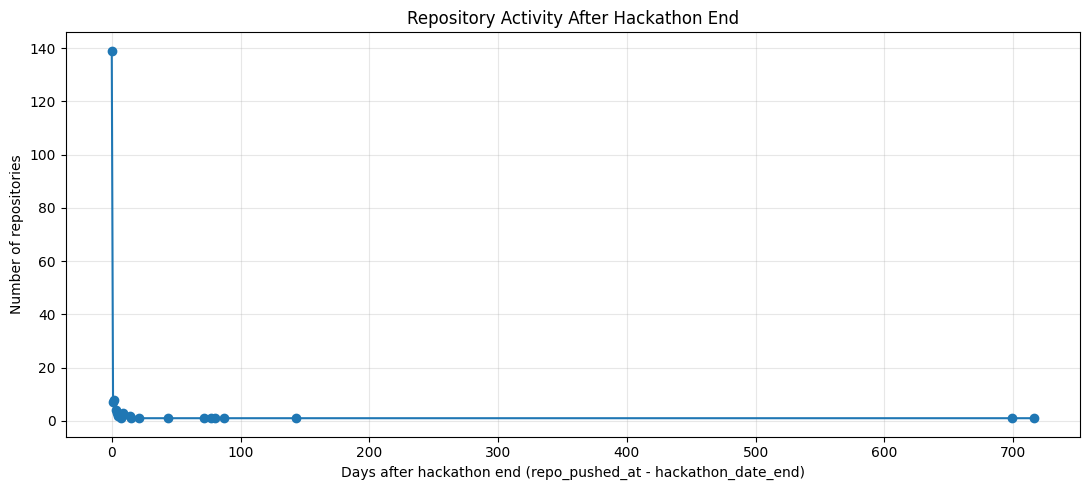

In [192]:
import matplotlib.pyplot as plt

# Ensure activity_days exists: days between last push and hackathon end date
if 'activity_days' not in repo_analysis_scored.columns:
    repo_analysis_scored['activity_days'] = (
        pd.to_datetime(repo_analysis_scored['repo_pushed_at'], errors='coerce', utc=True)
        - pd.to_datetime(repo_analysis_scored['hackathon_date_end'], errors='coerce', utc=True)
    ).dt.days.astype('Int64')

# Keep only activity on/after hackathon end
activity_after = repo_analysis_scored.loc[
    repo_analysis_scored['activity_days'].notna() & (repo_analysis_scored['activity_days'] >= 0),
    'activity_days'
].astype(int)

activity_counts = activity_after.value_counts().sort_index()

plt.figure(figsize=(11, 5))
activity_counts.plot(kind='line', marker='o', linewidth=1.5)
plt.title('Repository Activity After Hackathon End')
plt.xlabel('Days after hackathon end (repo_pushed_at - hackathon_date_end)')
plt.ylabel('Number of repositories')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [195]:
repo_analysis_scored[repo_analysis_scored['activity_days']>500]

,global_project_uid,project_uid,project_id,project_title,project_description,project_url,year,source_provider,hackathon_name,hackathon_location,...,hackathon_repo_score,hackathon_repo_flag,hackathon_repo_signals,commit_activity_signal,contributors_signal,repo_popularity_signal,strong_repo_text,metadata_error,weak_repo_text,activity_days
5,lauzhack:2023:id:4,id:4,4,BMS detction HCM,model learning and qualtitative feedback diagn...,https://github.com/Gabriel29062001/hackathon,2023,lauzhack,LauzHack 2023,"EPFL, Lausanne, Switzerland",...,5,certain,strong_repo_text|contributors_signal|commit_ac...,True,True,False,True,False,False,699
26,lauzhack:2023:id:25,id:25,25,FitHeart with Kangi,A friendly app for HCM patients to mainly rece...,https://github.com/abilevi5/FitHeart-with-Kang...,2023,lauzhack,LauzHack 2023,"EPFL, Lausanne, Switzerland",...,4,certain,strong_repo_text|commit_activity_signal,True,False,False,True,False,False,716


### classify by flag

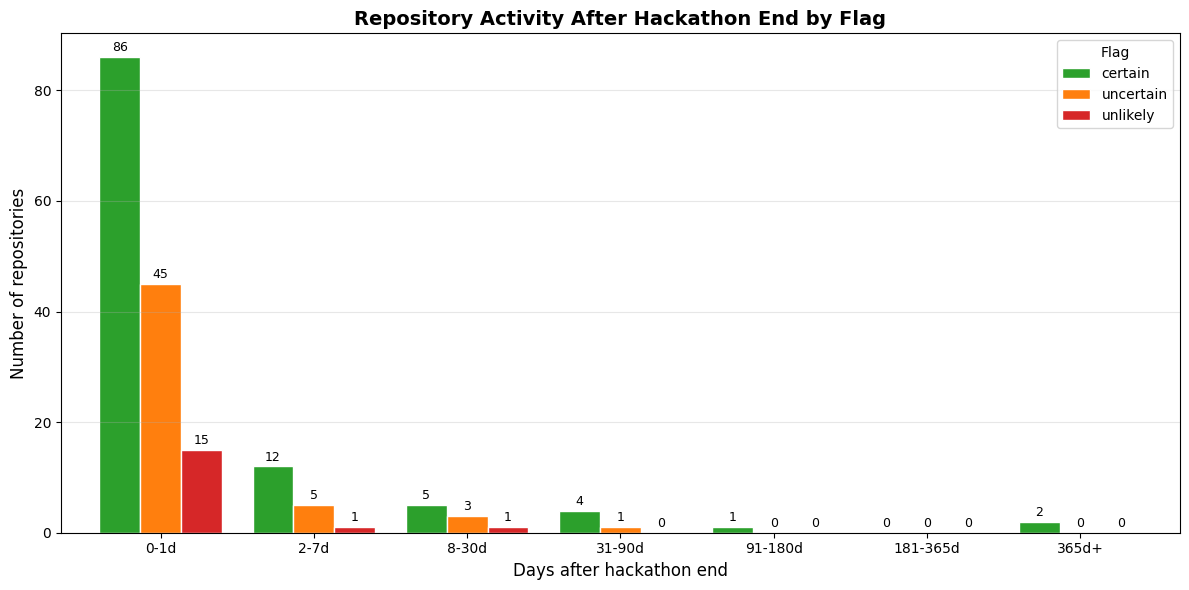

In [197]:
# Activity over time (days after hackathon end), colored by hackathon_repo_flag

if 'activity_days' not in repo_analysis_scored.columns:
    repo_analysis_scored['activity_days'] = (
        pd.to_datetime(repo_analysis_scored['repo_pushed_at'], errors='coerce', utc=True)
        - pd.to_datetime(repo_analysis_scored['hackathon_date_end'], errors='coerce', utc=True)
    ).dt.days.astype('Int64')

plot_df = repo_analysis_scored.loc[
    repo_analysis_scored['activity_days'].notna() & (repo_analysis_scored['activity_days'] >= 0)
].copy()
plot_df['activity_days'] = plot_df['activity_days'].astype(int)

# Bin activity_days into meaningful ranges
bins = [0, 1, 7, 30, 90, 180, 365, plot_df['activity_days'].max() + 1]
labels = ['0-1d', '2-7d', '8-30d', '31-90d', '91-180d', '181-365d', '365d+']
plot_df['activity_bin'] = pd.cut(plot_df['activity_days'], bins=bins, labels=labels, right=True, include_lowest=True)

flag_order = ['certain', 'uncertain', 'unlikely']
flag_colors = {
    'certain': '#2ca02c',
    'uncertain': '#ff7f0e',
    'unlikely': '#d62728',
}

counts = (
    plot_df.groupby(['activity_bin', 'hackathon_repo_flag'], observed=False)
    .size()
    .unstack(fill_value=0)
)
for f in flag_order:
    if f not in counts.columns:
        counts[f] = 0
counts = counts[flag_order]

fig, ax = plt.subplots(figsize=(12, 6))
counts.plot(
    kind='bar',
    color=[flag_colors[f] for f in flag_order],
    edgecolor='white',
    ax=ax,
    width=0.8,
)

# Add count labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=2)

ax.set_title('Repository Activity After Hackathon End by Flag', fontsize=14, fontweight='bold')
ax.set_xlabel('Days after hackathon end', fontsize=12)
ax.set_ylabel('Number of repositories', fontsize=12)
ax.legend(title='Flag', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

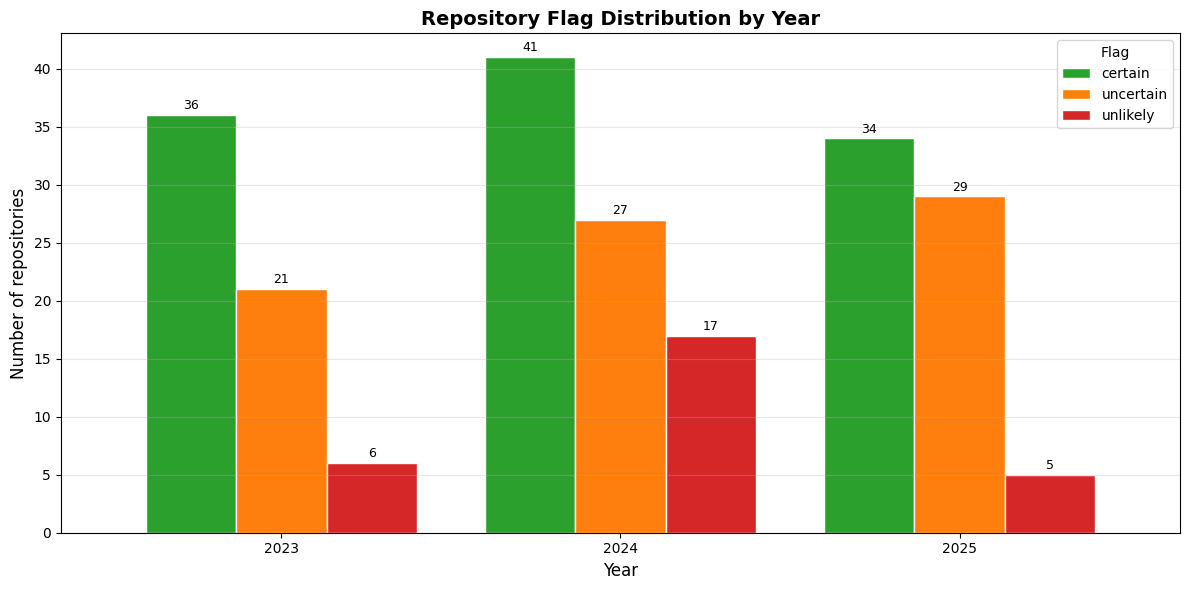

In [198]:
fig, ax = plt.subplots(figsize=(12, 6))

flag_order = ['certain', 'uncertain', 'unlikely']
flag_colors = {
    'certain': '#2ca02c',
    'uncertain': '#ff7f0e',
    'unlikely': '#d62728',
}

year_flag_counts = (
    repo_analysis_scored.groupby(['year', 'hackathon_repo_flag'], observed=False)
    .size()
    .unstack(fill_value=0)
)
for f in flag_order:
    if f not in year_flag_counts.columns:
        year_flag_counts[f] = 0
year_flag_counts = year_flag_counts[flag_order]

year_flag_counts.plot(
    kind='bar',
    color=[flag_colors[f] for f in flag_order],
    edgecolor='white',
    ax=ax,
    width=0.8,
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=2)

ax.set_title('Repository Flag Distribution by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of repositories', fontsize=12)
ax.legend(title='Flag', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [194]:
repo_scored_csv = DATA_ROOT / "all_lauzhack_repo_analysis_scored.csv"
repo_scored_parquet = DATA_ROOT / "all_lauzhack_repo_analysis_scored.parquet"
# repo_analysis_scored.to_csv(repo_scored_csv, index=False)

repo_scored_parquet_df = repo_analysis_scored.copy()
for col in repo_scored_parquet_df.columns:
    if repo_scored_parquet_df[col].map(lambda v: isinstance(v, (list, dict))).any():
        repo_scored_parquet_df[col] = repo_scored_parquet_df[col].map(
            lambda v: json.dumps(v, ensure_ascii=False) if isinstance(v, (list, dict)) else v
        )
repo_scored_parquet_df.to_parquet(repo_scored_parquet, index=False)

print("wrote:", repo_scored_csv)
print("wrote:", repo_scored_parquet)

wrote: /Users/eisha/Documents/hackathon_analysis/data/all_lauzhack_repo_analysis_scored.csv
wrote: /Users/eisha/Documents/hackathon_analysis/data/all_lauzhack_repo_analysis_scored.parquet
